In [234]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jockeroika/bankchurners/BankChurners.csv


In [235]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [236]:
df = pd.read_csv('/kaggle/input/datasets/jockeroika/bankchurners/BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [237]:
df.shape

(10127, 23)

In [238]:
df.drop(['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1, inplace=True)
df.isnull().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [239]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

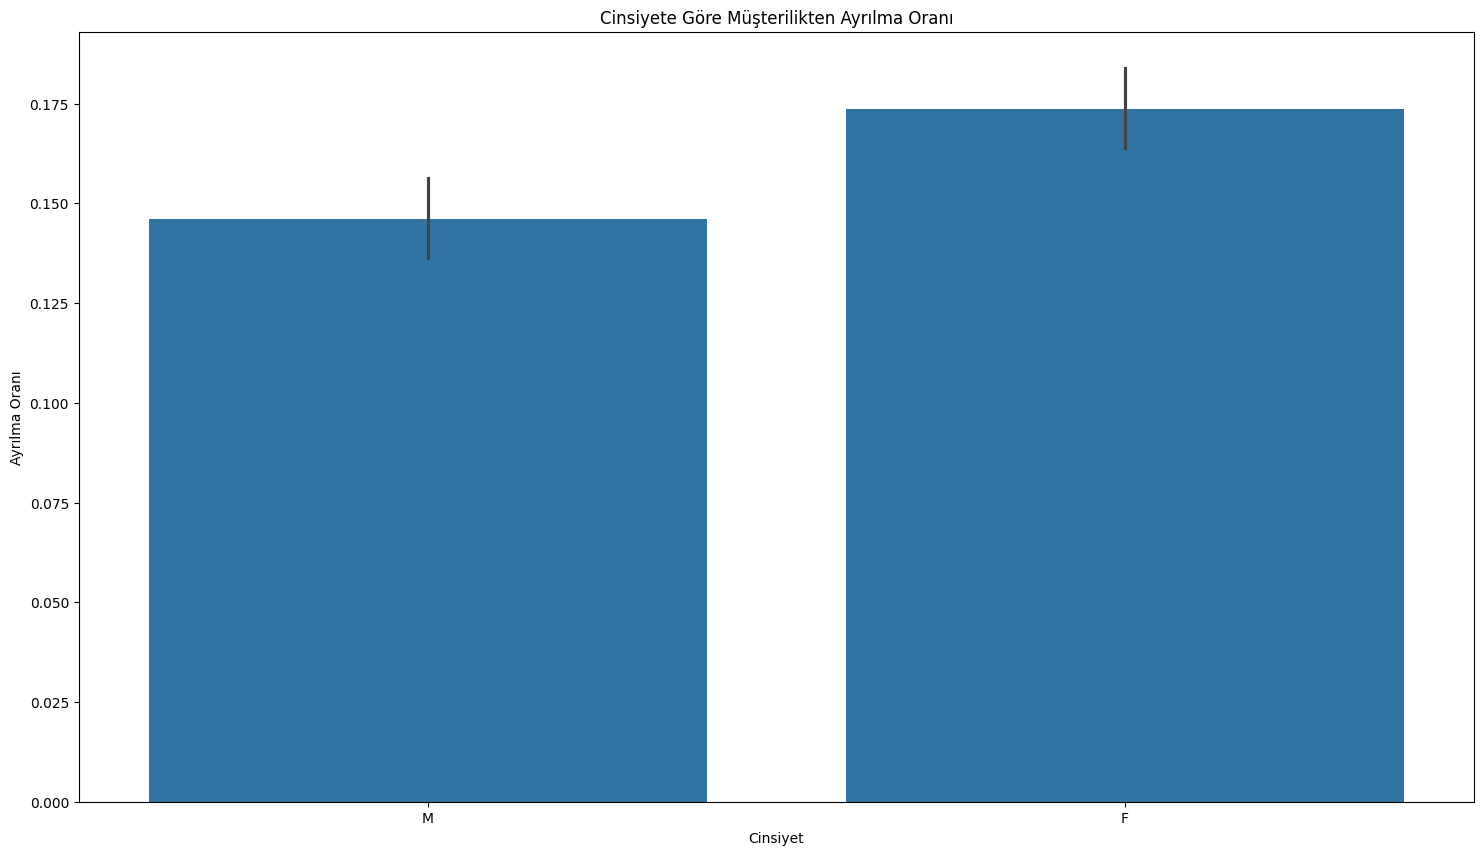

In [240]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer' : 0, 'Attrited Customer' : 1})

plt.figure(figsize=(18,10))
sns.barplot(data=df, x='Gender', y='Attrition_Flag')
plt.title('Cinsiyete Göre Müşterilikten Ayrılma Oranı')
plt.xlabel('Cinsiyet')
plt.ylabel('Ayrılma Oranı')
plt.show()

In [241]:
df.groupby('Gender')['Attrition_Flag'].value_counts()

Gender  Attrition_Flag
F       0                 4428
        1                  930
M       0                 4072
        1                  697
Name: count, dtype: int64

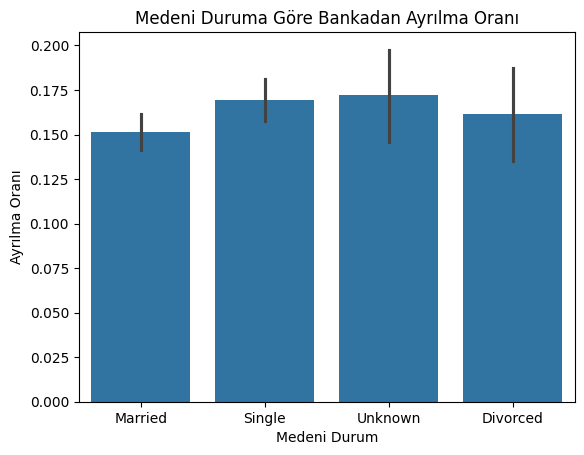

In [242]:
sns.barplot(data=df, x='Marital_Status', y='Attrition_Flag')
plt.title('Medeni Duruma Göre Bankadan Ayrılma Oranı')
plt.xlabel('Medeni Durum')
plt.ylabel('Ayrılma Oranı')
plt.show()

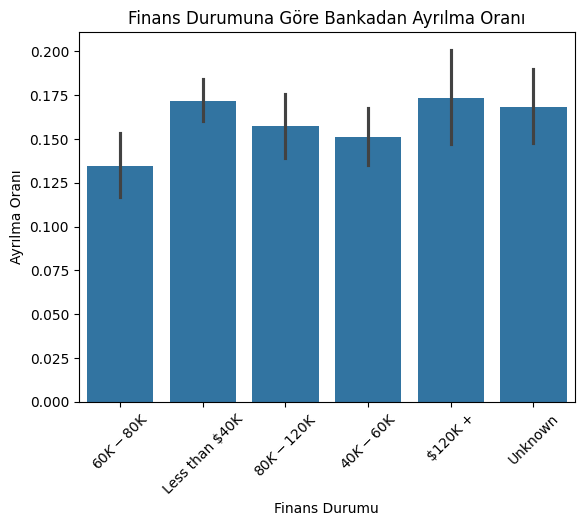

In [243]:
sns.barplot(data=df, x='Income_Category', y='Attrition_Flag')
plt.title('Finans Durumuna Göre Bankadan Ayrılma Oranı')
plt.xlabel('Finans Durumu')
plt.ylabel('Ayrılma Oranı')
plt.xticks(rotation=45)
plt.show()

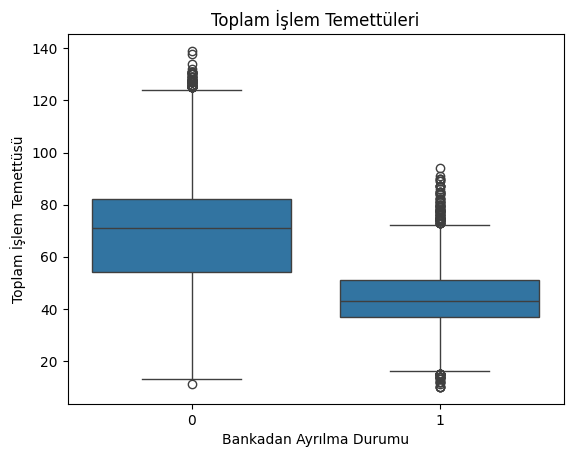

In [244]:
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct')
plt.title('Toplam İşlem Temettüleri')
plt.xlabel('Bankadan Ayrılma Durumu')
plt.ylabel('Toplam İşlem Temettüsü')
plt.show()

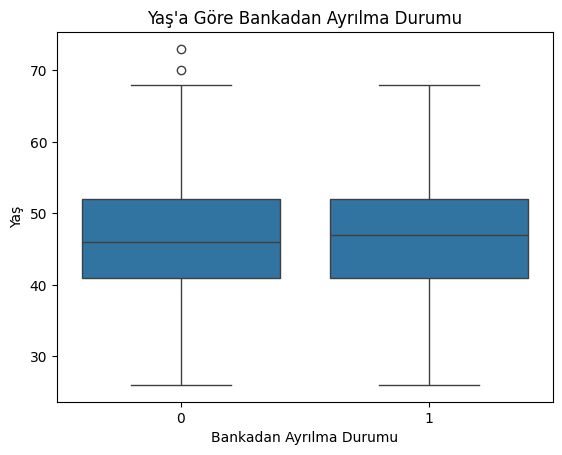

In [245]:
sns.boxplot(data=df, x='Attrition_Flag', y='Customer_Age')
plt.title("Yaş'a Göre Bankadan Ayrılma Durumu")
plt.xlabel('Bankadan Ayrılma Durumu')
plt.ylabel('Yaş')
plt.show()

In [246]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [248]:
df['Education_Level'].value_counts()

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

In [249]:
df['Marital_Status'].value_counts()

Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

In [250]:
df['Card_Category'].value_counts()

Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64

In [251]:
df['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

In [252]:
df['Income_Category'] = df['Income_Category'].map({'Unkown' : 60000, 'Less than $40K' : 35000, '$40K - $60K' : 50000, '$80K - $120K' : 100000, '$60K - $80K' : 70000, '$120K +' : 130000})
df['Gender'] = df['Gender'].map({'F' : 1, 'M' : 0})
df = pd.get_dummies(df, columns=['Marital_Status'])

In [253]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

df['Education_Level'] = df['Education_Level'].replace('Unknown', 'Graduate')
oe = OrdinalEncoder(categories=[
    ['Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
])
df['Education_Level'] = oe.fit_transform(df[['Education_Level']])
df['Education_Level'] = df['Education_Level'].fillna(df['Education_Level'].median())

oe2 = OrdinalEncoder(categories=[
    ['Blue', 'Silver', 'Gold', 'Platinum']
])
df['Card_Category'] = oe2.fit_transform(df[['Card_Category']])

In [254]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,0,45,0,3,1.0,70000.0,0.0,39,5,1,...,11914.0,1.335,1144,42,1.625,0.061,False,True,False,False
1,0,49,1,5,3.0,35000.0,0.0,44,6,1,...,7392.0,1.541,1291,33,3.714,0.105,False,False,True,False
2,0,51,0,3,3.0,100000.0,0.0,36,4,1,...,3418.0,2.594,1887,20,2.333,0.000,False,True,False,False
3,0,40,1,4,1.0,35000.0,0.0,34,3,4,...,796.0,1.405,1171,20,2.333,0.760,False,False,False,True
4,0,40,0,3,0.0,70000.0,0.0,21,5,1,...,4716.0,2.175,816,28,2.500,0.000,False,True,False,False


In [255]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition_Flag', axis = 1)
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [256]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [258]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=6, random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42),
    
}

def evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test):
    results = []

    for name, model in models.items():

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)


        accuracy = accuracy_score(y_test, y_pred)
        confusion = confusion_matrix(y_test, y_pred)
        classification = classification_report(y_test, y_pred)


        results.append({
            "name": name,
            "accuracy": accuracy
        })


        print(f"\nMODEL: {name}")
        print("=" * 40)
        print("Karmaşıklık Matrisi:")
        print(confusion)
        print("\nSınıflandırma Raporu:")
        print(classification)
        print(f"Accuracy: {accuracy:.4f}")


    return pd.DataFrame(results).sort_values(by=['accuracy'], ascending=False)


summary_table = evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test)


MODEL: Random Forest
Karmaşıklık Matrisi:
[[2106   19]
 [  98  309]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2125
           1       0.94      0.76      0.84       407

    accuracy                           0.95      2532
   macro avg       0.95      0.88      0.91      2532
weighted avg       0.95      0.95      0.95      2532

Accuracy: 0.9538

MODEL: XGBoost
Karmaşıklık Matrisi:
[[2087   38]
 [  42  365]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2125
           1       0.91      0.90      0.90       407

    accuracy                           0.97      2532
   macro avg       0.94      0.94      0.94      2532
weighted avg       0.97      0.97      0.97      2532

Accuracy: 0.9684
[LightGBM] [Info] Number of positive: 1220, number of negative: 6375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the o

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


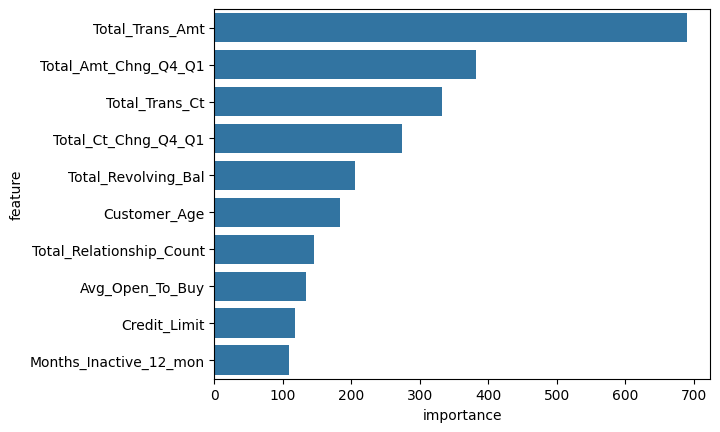

In [259]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': models['LightGBM'].feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=importance.head(10), x='importance', y='feature')
plt.show()